In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/brendan45774/test-file/tested.csv


In [2]:
df=pd.read_csv('/kaggle/input/datasets/brendan45774/test-file/tested.csv')

In [ ]:
df.info()

In [3]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [ ]:
df.groupby('Sex').Sex.size()

In [ ]:
df.isnull().sum()

In [ ]:
df['Survived'].mean()

In [ ]:
df['Survived'].value_counts()

In [ ]:
df[df['Age'] == df['Age'].max()]

In [ ]:
df[df['Survived'] == 1]

In [ ]:
df.columns

In [ ]:
df[df['Sex'] == 'female'].sort_values(by= 'Age', ascending= False).fillna('unidentified')

In [ ]:
df.set_index('Pclass')

In [ ]:
df.groupby('Age').size()

In [ ]:
df['Age']= df['Age'].replace([np.inf, -np.inf], np.nan)
df['Age']= df['Age'].fillna(0)
df['Age'].astype('int').sort_values()

In [ ]:
df.rename(columns= {'Pclass': 'PassengerClass'}).set_index('PassengerClass')

In [ ]:
df['Pclass']= df['Pclass'].replace({1: 'Upperclass', 2: 'Midclass', 3: 'Lowerclass'})
df= df.drop(columns= [1,2,3])
df.head()

In [ ]:
df['Fare'].agg(['max','min'])

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt


<Axes: title={'center': 'Age distribution of passengers'}, xlabel='Age', ylabel='Count'>

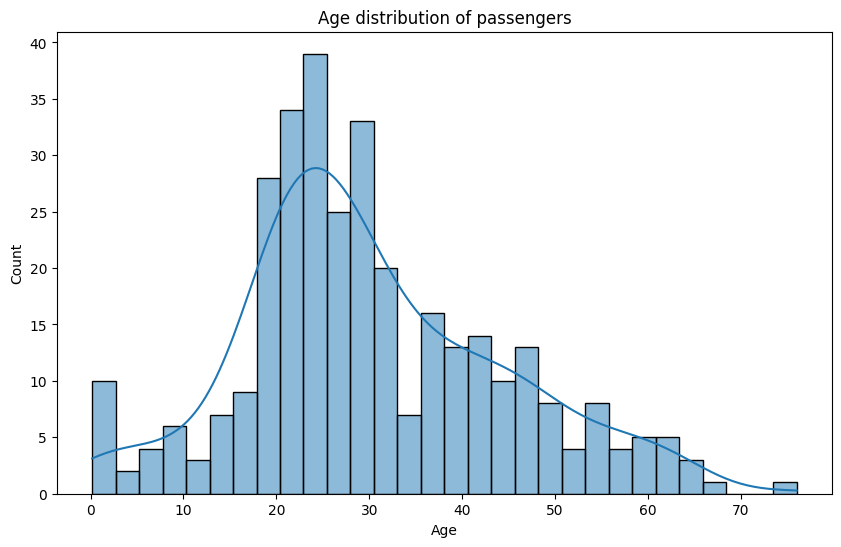

In [19]:
plt.figure(figsize=(10,6))
plt.title("Age distribution of passengers")
sns.histplot(df['Age'].dropna(), bins= 30, kde= True)

Text(0.5, 1.0, 'Survival by Gender')

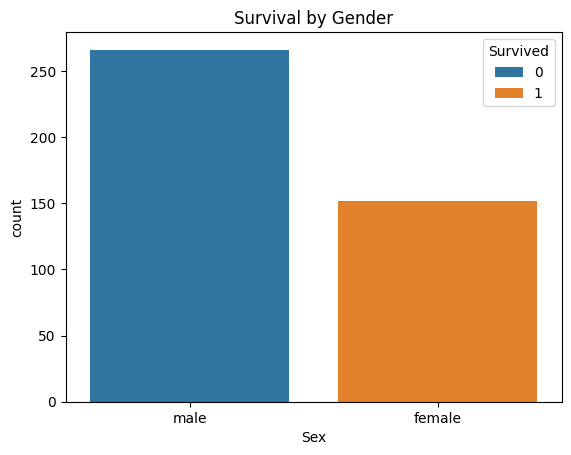

In [24]:
sns.countplot(x= 'Sex', hue= 'Survived', data= df)
plt.title("Survival by Gender")

Text(0.5, 1.0, 'Fare by Passenger Class')

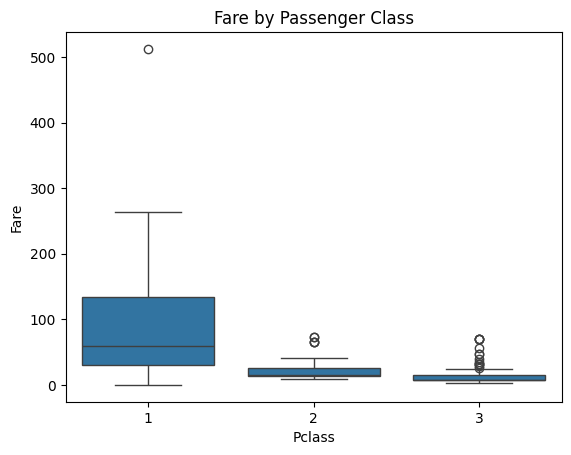

In [28]:
sns.boxplot(x= 'Pclass', y= 'Fare', data= df)
plt.title("Fare by Passenger Class")

Text(0.5, 1.0, 'Age vs Fare on the basis of Survival')

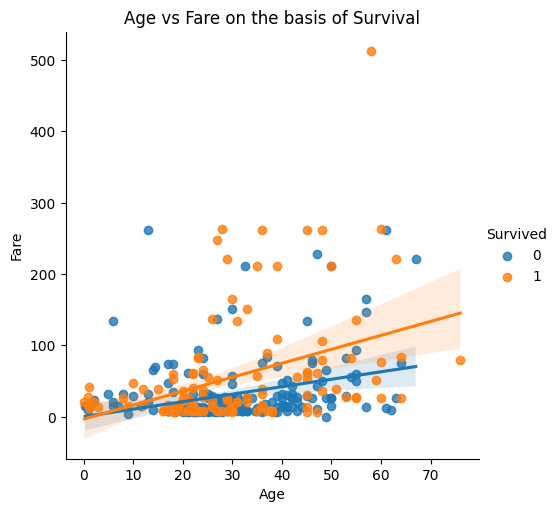

In [44]:
sns.lmplot(x= 'Age', y= 'Fare', hue= 'Survived', data= df)
plt.title("Age vs Fare on the basis of Survival")

Text(0.5, 1.0, 'Age vs Fare concentration')

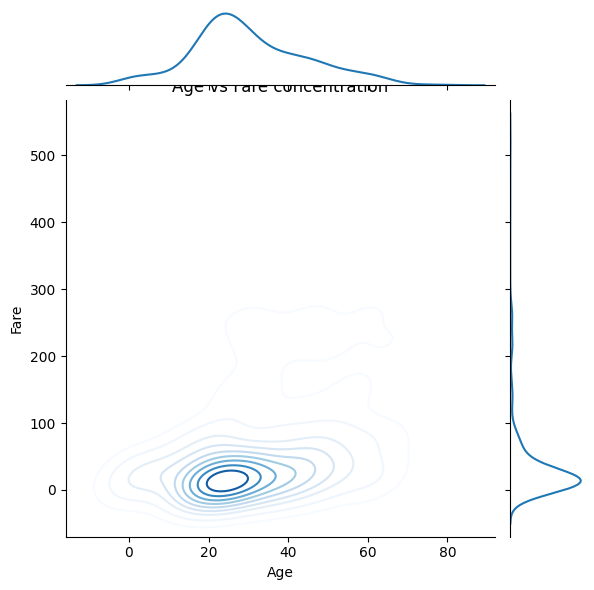

In [61]:
sns.jointplot(x= 'Age', y= 'Fare', data= df, kind= 'kde', cmap='Blues')
plt.title("Age vs Fare concentration")

Text(0.5, 1.0, 'Full overview')

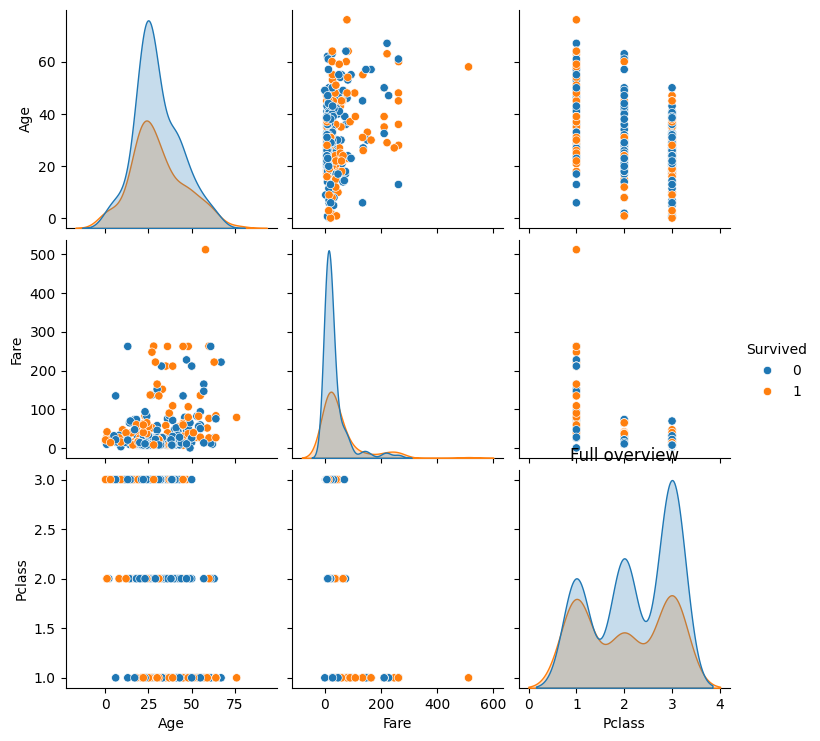

In [47]:
sns.pairplot(df[['Age', 'Fare', 'Pclass', 'Survived']].dropna(), hue='Survived')
plt.title("Full overview")